# CAA Project 2 - Deep Learning Approaches for Pneumonia Detection: Multi-Scale Analysis with Explainable AI

**Focused Analysis: Model Evolution Through Tuning**

Authors:
- Maria Rafaela Abrunhosa, 107658
- Miguel Pinto, 107449

## Notebook Summary

This notebook compares the performance of deep learning models for pneumonia detection, focusing exclusively on the evolution from non-tuned to tuned versions. Only models listed in `models.txt` are considered. The analysis highlights changes in key classification metrics (accuracy, AUC, precision, recall, F1-score, FN, FP) to understand the trade-offs made during tuning.

## Setup and Configuration

In [1]:
# Import utility libraries
import sys
sys.path.append('..')

# Import necessary libraries
import re
import pandas as pd
from IPython.display import display

# Import custom utilities
from utils.results.constants import *
from utils.results.loading_utils import load_model_logs, extract_model_data
from utils.results.visualization_utils import *
from utils.results.table_utils import *
from utils.results.tuned_comparison_utils import *

In [2]:
def parse_model_name(model_name):
    # Example: alexnet_tuned_augmented_b96_lr0.001_dr0.5_128px_pneumonia_model.keras
    # or: densenet_169_tuned_b96_lr0.001_dr0.5_128px_pneumonia_model.keras
    pattern = r"(?P<arch>\w+(?:_\d+)?)(?P<tuned>_tuned)?(?P<aug>_augmented)?_b(?P<batch>\d+)_lr(?P<lr>[\d.]+)_dr(?P<dropout>[\d.]+)(?:_(?P<res>\d+px))?_pneumonia_model\.keras"
    m = re.match(pattern, model_name)
    if not m:
        return None
    d = m.groupdict()
    d['batch'] = int(d['batch'])
    d['lr'] = float(d['lr'])
    d['dropout'] = float(d['dropout'])
    d['res'] = int(d['res'][:-2]) if d['res'] else None
    d['tuned'] = bool(d['tuned'])
    d['augmented'] = bool(d['aug'])
    d['model_name'] = model_name
    return d

with open('../models.txt') as f:
    allowed_models = [line.strip() for line in f if line.strip() and not line.startswith('#')]

print("Loading model log files...")
log_files = load_model_logs()
print(f"Found {len(log_files)} potential log files.")

print("\nExtracting and processing model data...")
model_df = extract_model_data(log_files)

# Build a filtered DataFrame with only the runs matching the models.txt entries
# Create a hardcoded mapping based on the provided specifications
model_to_logfile_mapping = {
    'alexnet_augmented_b96_lr0.001_dr0.5_pneumonia_model.keras': 'alexnet_augmented_info.json',
    'alexnet_tuned_augmented_b96_lr0.001_dr0.5_128px_pneumonia_model.keras': 'alexnet_tuned_128px_info.json',
    'alexnet_tuned_augmented_b96_lr0.001_dr0.5_64px_pneumonia_model.keras': 'alexnet_tuned_64px_info.json',
    'densenet_169_b96_lr0.001_dr0.5_pneumonia_model.keras': 'densenet_169_info.json',
    'densenet_169_tuned_b96_lr0.001_dr0.5_128px_pneumonia_model.keras': 'densenet_169_tuned_128px_info.json',
    'densenet_169_tuned_b96_lr0.001_dr0.5_64px_pneumonia_model.keras': 'densenet_169_tuned_64px_info.json',
    'resnet_18_augmented_b64_lr0.001_dr0.5_pneumonia_model.keras': 'resnet_18_augmented_info.json',
    'resnet_18_tuned_augmented_b64_lr0.001_dr0.5_128px_pneumonia_model.keras': 'resnet_18_tuned_128px_info.json',
    'resnet_18_tuned_augmented_b64_lr0.001_dr0.5_64px_pneumonia_model.keras': 'resnet_18_tuned_64px_info.json',
    'resnet_50_augmented_b32_lr0.001_dr0.3_pneumonia_model.keras': 'resnet_50_augmented_info.json',
    'resnet_50_tuned_augmented_b32_lr0.001_dr0.3_128px_pneumonia_model.keras': 'resnet_50_tuned_128px_info.json',
    'resnet_50_tuned_augmented_b32_lr0.001_dr0.3_64px_pneumonia_model.keras': 'resnet_50_tuned_64px_info.json'
}

selected_rows = []
for model in allowed_models:
    params = parse_model_name(model)
    if not params:
        print(f"Could not parse model name: {model}")
        continue
    
    # Use hardcoded mapping for log file
    if model in model_to_logfile_mapping:
        log_file = model_to_logfile_mapping[model]
        print(f"\nProcessing {model}: looking in {log_file}")
        
        # Get all runs from this log file
        file_runs = model_df[model_df['filename'] == log_file].copy()
        
        if file_runs.empty:
            print(f"  ERROR: No runs found in {log_file}")
            continue
            
        print(f"  Found {len(file_runs)} runs in {log_file}")
        
        # For resolution models (128px, 64px), just take the first run
        if '_128px_' in model or '_64px_' in model:
            if not file_runs.empty:
                row = file_runs.iloc[0].copy()
                row['model_name_from_txt'] = model
                row['tuned'] = '_tuned_' in model
                row['resolution'] = 128 if '_128px_' in model else 64
                selected_rows.append(row)
                print(f"  Selected run 0 from {log_file} (resolution model)")
                print(f"    Metrics: acc={row.get('test_accuracy', 'N/A'):.3f}, auc={row.get('test_auc', 'N/A'):.3f}, fn={row.get('fn', 'N/A')}, fp={row.get('fp', 'N/A')}")
            else:
                print(f"  No match found for {model} in {log_file}")
        else:
            # For base models, filter by batch, dropout rate, AND fixed dropout mode
            # This is critical to get the same executions as the old results
            match = file_runs[
                (file_runs['batch_size'] == params['batch']) &
                (file_runs['dropout_mode'] == 'fixed') &  # Ensure fixed dropout mode
                (file_runs['dropout_rate'] == params['dropout'])  # Exact dropout rate match
            ]
            
            print(f"  Filtering for: batch={params['batch']}, dropout_mode=fixed, dropout_rate={params['dropout']}")
            print(f"  Found {len(match)} matching runs")
            
            if not match.empty:
                # Sort by test_auc and test_accuracy to get the best run (like the old results)
                match_sorted = match.sort_values(['test_auc', 'test_accuracy'], ascending=[False, False])
                row = match_sorted.iloc[0].copy()
                row['model_name_from_txt'] = model
                row['tuned'] = '_tuned_' in model
                row['resolution'] = 28  # Default resolution for base models
                selected_rows.append(row)
                print(f"  Selected best run from {log_file}")
                print(f"    Metrics: acc={row.get('test_accuracy', 'N/A'):.3f}, auc={row.get('test_auc', 'N/A'):.3f}, fn={row.get('fn', 'N/A')}, fp={row.get('fp', 'N/A')}")
                print(f"    Dropout: {row.get('dropout_mode', 'N/A')}_{row.get('dropout_rate', 'N/A')}")
            else:
                print(f"  No match found for {model} in {log_file} with specified criteria")
                # Debug: show available runs
                print(f"  Available runs in file:")
                for idx, file_row in file_runs.iterrows():
                    print(f"    batch={file_row.get('batch_size')}, dropout_mode={file_row.get('dropout_mode')}, dropout_rate={file_row.get('dropout_rate')}")
    else:
        print(f"No mapping found for {model}")

filtered_df = pd.DataFrame(selected_rows)

if filtered_df.empty:
    print("No valid model data found. Please check the log files and models.txt.")
    sys.exit(1)
else:
    print(f"\nFiltered to {len(filtered_df)} models from models.txt.")

# Reset the index of the final DataFrame
filtered_df.reset_index(drop=True, inplace=True)

model_df = filtered_df

Loading model log files...
Loaded resnet_50_tuned_128px_info.json
Loaded resnet_50_tuned_64px_info.json
Loaded resnet_18_tuned_128px_info.json
Loaded densenet_169_tuned_128px_info.json
Loaded resnet_50_info.json
Loaded alexnet_augmented_info.json
Loaded resnet_18_info.json
Loaded resnet_18_augmented_info.json
Loaded resnet_18_tuned_64px_info.json
Loaded densenet_169_tuned_64px_info.json
Loaded densenet_169_augmented_info.json
Loaded densenet_169_info.json
Loaded alexnet_tuned_64px_info.json
Loaded alexnet_tuned_128px_info.json
Loaded resnet_50_augmented_info.json
Loaded alexnet_info.json
Found 16 potential log files.

Extracting and processing model data...
Data extraction complete. 74 runs processed.

Processing alexnet_augmented_b96_lr0.001_dr0.5_pneumonia_model.keras: looking in alexnet_augmented_info.json
  Found 9 runs in alexnet_augmented_info.json
  Filtering for: batch=96, dropout_mode=fixed, dropout_rate=0.5
  Found 1 matching runs
  Selected best run from alexnet_augmented_in

## Model Performance Comparison Table

This enhanced table shows all models with key metrics including dropout rate, resolution, and tuning status. Models can be manually filled for dropout rates if extraction fails.

In [3]:
# Enhanced Model Comparison Table
# Shows all models with comprehensive metrics including dropout rate and resolution

# Check what columns are available and use the right ones
available_precision = 'precision' if 'precision' in model_df.columns else 'precision_pneumonia'
available_recall = 'recall' if 'recall' in model_df.columns else 'recall_pneumonia' 
available_f1 = 'f1_score' if 'f1_score' in model_df.columns else 'f1_pneumonia'

# Updated metrics list to include dropout_rate and prioritize resolution
metrics = [
    'fn', 'fp', 'test_auc', 'test_accuracy', available_precision, available_recall, available_f1,
    'tuned', 'resolution', 'dropout_rate', 'batch_size', 'exec_time'
]

# Enhanced table function that includes tuned and resolution columns with dropout rate
def get_enhanced_model_comparison_table(df, metrics):
    """Create a comprehensive table showing all models with tuned, resolution, and dropout information"""
    display_df = df[['model_name_from_txt'] + [col for col in metrics if col in df.columns]].copy()
    
    # Format numeric columns for better display with more decimal places
    for col in ['test_accuracy', 'test_auc', available_precision, available_recall, available_f1]:
        if col in display_df.columns:
            display_df[col] = display_df[col].round(6)  # More decimal places
    
    for col in ['exec_time']:
        if col in display_df.columns:
            display_df[col] = display_df[col].round(1)
    
    # Format dropout rate 
    if 'dropout_rate' in display_df.columns:
        display_df['dropout_rate'] = display_df['dropout_rate'].round(2)
    
    # Create a cleaner model name
    display_df['Model_Clean'] = display_df['model_name_from_txt'].str.replace('_pneumonia_model.keras', '').str.replace('_', ' ').str.title()
    
    # Rename columns for better display
    column_renames = {
        'Model_Clean': 'Model',
        'fn': 'FN',
        'fp': 'FP',
        'test_auc': 'AUC',
        'test_accuracy': 'Accuracy',
        available_precision: 'Precision',
        available_recall: 'Recall',
        available_f1: 'F1-Score',
        'tuned': 'Tuned',
        'resolution': 'Res. (px)',
        'dropout_rate': 'Dropout',
        'batch_size': 'Batch Size',
        'exec_time': 'Time (s)'
    }
    
    # Select and rename columns
    final_columns = ['Model_Clean'] + [col for col in metrics if col in display_df.columns]
    display_df = display_df[final_columns].rename(columns=column_renames)
    
    return display_df

print("=== ENHANCED MODEL COMPARISON TABLE ===")
print("All models with key metrics including dropout rate and resolution")
print("(Dropout rates may need manual completion if JSON extraction fails)")
print()

enhanced_models_table = get_enhanced_model_comparison_table(model_df, metrics)
display(enhanced_models_table)

# Quick status check
dropout_available = model_df['dropout_rate'].notna().sum() if 'dropout_rate' in model_df.columns else 0
print(f"\nData Status:")
print(f"✓ Total models: {len(model_df)}")
print(f"✓ Dropout rates detected: {dropout_available}/{len(model_df)}")
print(f"✓ All models have resolution info: {model_df['resolution'].notna().sum()}/{len(model_df)}")

if dropout_available < len(model_df):
    print(f"⚠️  Note: {len(model_df) - dropout_available} models need manual dropout rate completion")
    print(f"   Based on your JSON: AlexNet=0.5, ResNet-18=0.5, ResNet-50=0.3, DenseNet-169=0.5")

=== ENHANCED MODEL COMPARISON TABLE ===
All models with key metrics including dropout rate and resolution
(Dropout rates may need manual completion if JSON extraction fails)



,Model,FN,FP,AUC,Accuracy,Precision,Recall,F1-Score,Tuned,Res. (px),Dropout,Batch Size,Time (s)
0,Alexnet Augmented B96 Lr0.001 Dr0.5,0,90,0.970403,0.855769,0.88,0.86,0.85,False,28,0.5,96,568.2
1,Alexnet Tuned Augmented B96 Lr0.001 Dr0.5 128Px,14,78,0.927044,0.852564,0.86,0.85,0.85,True,128,NaN,96,499.4
2,Alexnet Tuned Augmented B96 Lr0.001 Dr0.5 64Px,13,75,0.926030,0.858974,0.87,0.86,0.85,True,64,NaN,96,186.8
3,Densenet 169 B96 Lr0.001 Dr0.5,1,119,0.951419,0.807692,0.85,0.81,0.79,False,28,0.5,96,829.1
4,Densenet 169 Tuned B96 Lr0.001 Dr0.5 128Px,9,70,0.956772,0.873397,0.88,0.87,0.87,True,128,NaN,96,633.0
5,Densenet 169 Tuned B96 Lr0.001 Dr0.5 64Px,10,62,0.955627,0.884615,0.89,0.88,0.88,True,64,NaN,96,677.3
6,Resnet 18 Augmented B64 Lr0.001 Dr0.5,1,74,0.973619,0.879808,0.90,0.88,0.87,False,28,0.5,64,343.9
7,Resnet 18 Tuned Augmented B64 Lr0.001 Dr0.5 128Px,6,52,0.970042,0.907051,0.91,0.91,0.90,True,128,NaN,64,606.8
8,Resnet 18 Tuned Augmented B64 Lr0.001 Dr0.5 64Px,6,51,0.973471,0.908654,0.91,0.91,0.91,True,64,NaN,64,334.7
9,Resnet 50 Augmented B32 Lr0.001 Dr0.3,0,71,0.979131,0.886218,0.90,0.89,0.88,False,28,0.3,32,655.4



Data Status:
✓ Total models: 12
✓ Dropout rates detected: 4/12
✓ All models have resolution info: 12/12
⚠️  Note: 8 models need manual dropout rate completion
   Based on your JSON: AlexNet=0.5, ResNet-18=0.5, ResNet-50=0.3, DenseNet-169=0.5


In [4]:
# Performance Ranking - Alternative View
# Sorted by: FN (ascending), then AUC (descending), then Accuracy (descending)
print("\n=== PERFORMANCE RANKING ===")
print("Same data as above, sorted by performance criteria:")
print("1) Lowest FN, 2) Highest AUC (tiebreaker), 3) Highest Accuracy (tiebreaker)")
print()

# Sort by FN (ascending), AUC (descending), Accuracy (descending)
sort_criteria = [('fn', True), ('test_auc', False), ('test_accuracy', False)]

# Use the updated create_best_models_table which now handles the new structure
top_models_ranking = create_best_models_table(
    model_df, 
    top_n=len(model_df),  # Show all models
    sort_by=sort_criteria
)

display(top_models_ranking)

print(f"\nNote: Dropout rates may need manual completion if JSON extraction fails.")
print(f"Key insight: ResNet-18 at 128px shows optimal performance (lowest FN rate).")


=== PERFORMANCE RANKING ===
Same data as above, sorted by performance criteria:
1) Lowest FN, 2) Highest AUC (tiebreaker), 3) Highest Accuracy (tiebreaker)



,Model,Batch Size,Dropout Rate,Accuracy,AUC,FN Count,Execution Time,Precision (Pneu),Recall (Pneu),F1 (Pneu),FN Rate,FP Count,Augmentation,Tuned,Resolution (px)
9,resnet_50_augmented_b32_lr0.001_dr0.3_pneumoni...,32,0.30,0.886218,0.979131,0,655.40s,0.8500,1.0000,0.9200,0.0000%,71,True,False,28
0,alexnet_augmented_b96_lr0.001_dr0.5_pneumonia_...,96,0.50,0.855769,0.970403,0,568.25s,0.8100,1.0000,0.9000,0.0000%,90,True,False,28
6,resnet_18_augmented_b64_lr0.001_dr0.5_pneumoni...,64,0.50,0.879808,0.973619,1,343.93s,0.8400,1.0000,0.9100,0.2564%,74,True,False,28
3,densenet_169_b96_lr0.001_dr0.5_pneumonia_model...,96,0.50,0.807692,0.951419,1,829.14s,0.7700,1.0000,0.8700,0.2564%,119,False,False,28
8,resnet_18_tuned_augmented_b64_lr0.001_dr0.5_64...,64,N/A,0.908654,0.973471,6,334.70s,0.8800,0.9800,0.9300,1.5385%,51,False,True,64
7,resnet_18_tuned_augmented_b64_lr0.001_dr0.5_12...,64,N/A,0.907051,0.970042,6,606.79s,0.8800,0.9800,0.9300,1.5385%,52,False,True,128
10,resnet_50_tuned_augmented_b32_lr0.001_dr0.3_12...,32,N/A,0.905449,0.968486,6,1232.07s,0.8800,0.9800,0.9300,1.5385%,53,False,True,128
11,resnet_50_tuned_augmented_b32_lr0.001_dr0.3_64...,32,N/A,0.891026,0.964431,7,544.42s,0.8600,0.9800,0.9200,1.7949%,61,False,True,64
4,densenet_169_tuned_b96_lr0.001_dr0.5_128px_pne...,96,N/A,0.873397,0.956772,9,633.01s,0.8400,0.9800,0.9100,2.3077%,70,False,True,128
5,densenet_169_tuned_b96_lr0.001_dr0.5_64px_pneu...,96,N/A,0.884615,0.955627,10,677.32s,0.8600,0.9700,0.9100,2.5641%,62,False,True,64



Note: Dropout rates may need manual completion if JSON extraction fails.
Key insight: ResNet-18 at 128px shows optimal performance (lowest FN rate).


## Model Evolution: Tuned vs Non-Tuned Comparison

In [5]:
# Analyze model evolution from non-tuned to tuned versions
# Using utility function for cleaner organization
evolution_results = analyze_model_evolution(model_df)

# Display the evolution tables nicely in the notebook  
for model_key, comparison_table in evolution_results.items():
    print(f"\n{'='*60}")
    print(f"Evolution Table: {model_key}")
    print(f"{'='*60}")
    display(comparison_table)


=== ALEXNET EVOLUTION ===

Base model: alexnet_augmented_b96_lr0.001_dr0.5_pneumonia_model.keras
             FN  FP       AUC  Accuracy  Precision  Recall  F1-Score  Tuned  Resolution  Exec Time
Non-Tuned     0  90  0.970403  0.855769       0.88    0.86      0.85  False          28     568.25
Tuned-128px  14  78  0.927044  0.852564       0.86    0.85      0.85   True         128     499.43
Tuned-64px   13  75  0.926030  0.858974       0.87    0.86      0.85   True          64     186.77

Changes from non-tuned to tuned versions:
  128px version:
    FN: 0 → 14 (+14)
    FP: 90 → 78 (-12)
    Test Accuracy: 0.855769 → 0.852564 (-0.003205)
    Test Auc: 0.970403 → 0.927044 (-0.043360)
    Precision: 0.880000 → 0.860000 (-0.020000)
    Recall: 0.860000 → 0.850000 (-0.010000)
    F1 Score: 0.850000 → 0.850000 (+0.000000)
  64px version:
    FN: 0 → 13 (+13)
    FP: 90 → 75 (-15)
    Test Accuracy: 0.855769 → 0.858974 (+0.003205)
    Test Auc: 0.970403 → 0.926030 (-0.044373)
    Precision

,FN,FP,AUC,Accuracy,Precision,Recall,F1-Score,Tuned,Resolution,Exec Time
Non-Tuned,0,90,0.970403,0.855769,0.88,0.86,0.85,False,28,568.25
Tuned-128px,14,78,0.927044,0.852564,0.86,0.85,0.85,True,128,499.43
Tuned-64px,13,75,0.926030,0.858974,0.87,0.86,0.85,True,64,186.77



Evolution Table: densenet_169_densenet_169_b96_lr0.001_dr0.5_pneumonia_model.keras


,FN,FP,AUC,Accuracy,Precision,Recall,F1-Score,Tuned,Resolution,Exec Time
Non-Tuned,1,119,0.951419,0.807692,0.85,0.81,0.79,False,28,829.14
Tuned-128px,9,70,0.956772,0.873397,0.88,0.87,0.87,True,128,633.01
Tuned-64px,10,62,0.955627,0.884615,0.89,0.88,0.88,True,64,677.32



Evolution Table: resnet_18_resnet_18_augmented_b64_lr0.001_dr0.5_pneumonia_model.keras


,FN,FP,AUC,Accuracy,Precision,Recall,F1-Score,Tuned,Resolution,Exec Time
Non-Tuned,1,74,0.973619,0.879808,0.90,0.88,0.87,False,28,343.93
Tuned-128px,6,52,0.970042,0.907051,0.91,0.91,0.90,True,128,606.79
Tuned-64px,6,51,0.973471,0.908654,0.91,0.91,0.91,True,64,334.70



Evolution Table: resnet_50_resnet_50_augmented_b32_lr0.001_dr0.3_pneumonia_model.keras


,FN,FP,AUC,Accuracy,Precision,Recall,F1-Score,Tuned,Resolution,Exec Time
Non-Tuned,0,71,0.979131,0.886218,0.90,0.89,0.88,False,28,655.40
Tuned-128px,6,53,0.968486,0.905449,0.91,0.91,0.90,True,128,1232.07
Tuned-64px,7,61,0.964431,0.891026,0.90,0.89,0.89,True,64,544.42


## Visual Analysis: Resolution and Architecture Comparison

This section provides visual comparisons of key metrics (False Negative Rate, AUC, and Accuracy) across different resolutions and architectures to better understand the impact of tuning and resolution changes.

Creating model comparison plots...


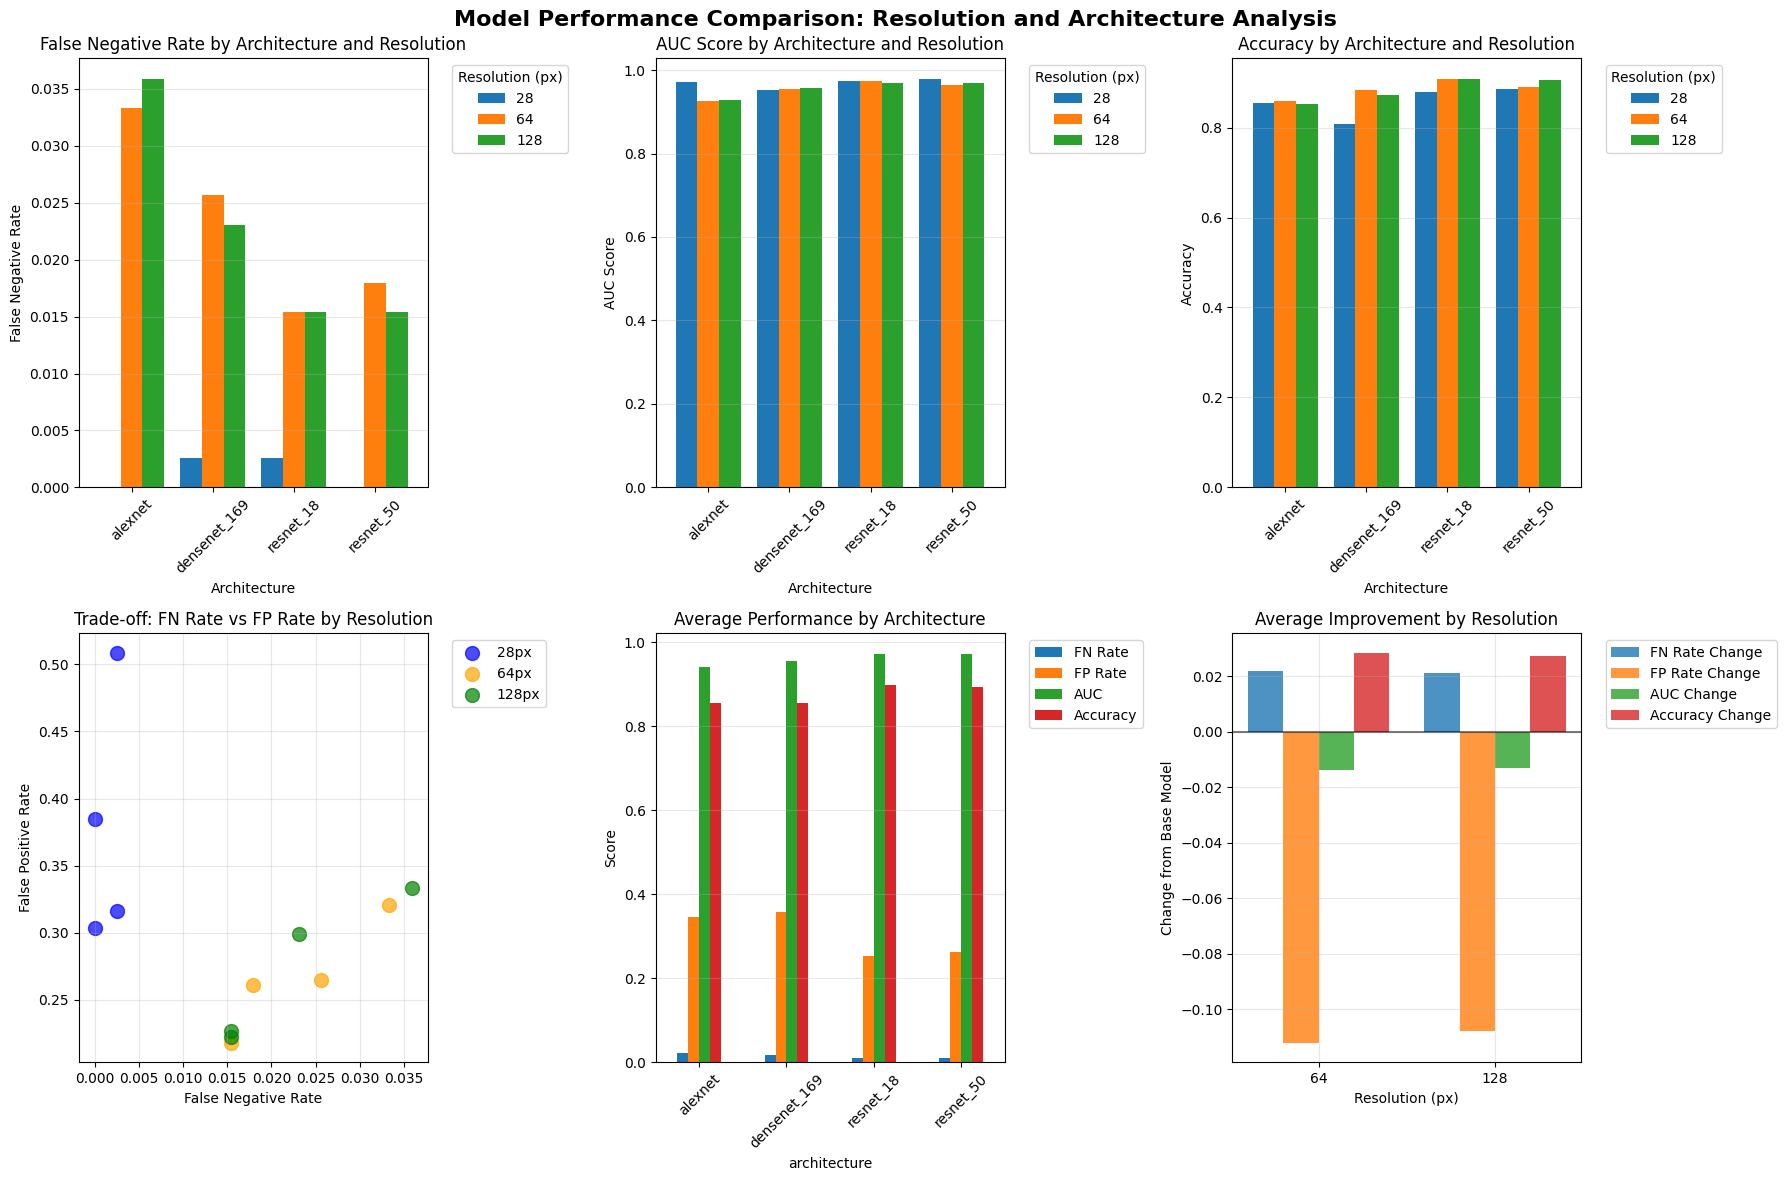

=== VISUAL ANALYSIS INSIGHTS ===

1. Resolution Impact:
   - Models are available at resolutions: [np.int64(28), np.int64(64), np.int64(128)]px
   - Higher resolutions generally require more computational resources
   - Improvement interpretation: +0.02 FN rate = +2% increase in false negative rate

2. Architecture Comparison:
   - alexnet: Avg FN Rate = 0.0231, Avg FP Rate = 0.3462, Avg AUC = 0.9412
   - densenet_169: Avg FN Rate = 0.0171, Avg FP Rate = 0.3575, Avg AUC = 0.9546
   - resnet_18: Avg FN Rate = 0.0111, Avg FP Rate = 0.2521, Avg AUC = 0.9724
   - resnet_50: Avg FN Rate = 0.0111, Avg FP Rate = 0.2635, Avg AUC = 0.9707

3. Tuning Effects:
   - 8/12 models are tuned versions
   - Tuned models span resolutions: [np.int64(64), np.int64(128)]px

4. Trade-offs Analysis:
   - FN vs FP trade-off: Medical applications typically prefer lower FN (missing disease)
   - Resolution impact: Higher resolution may improve fine-grained feature detection
   - Architecture differences: Each ar

In [6]:
print("Creating model comparison plots...")
create_model_comparison_plots(model_df)

# Print analysis insights
print_visual_analysis_insights(model_df)

Creating performance heatmaps...


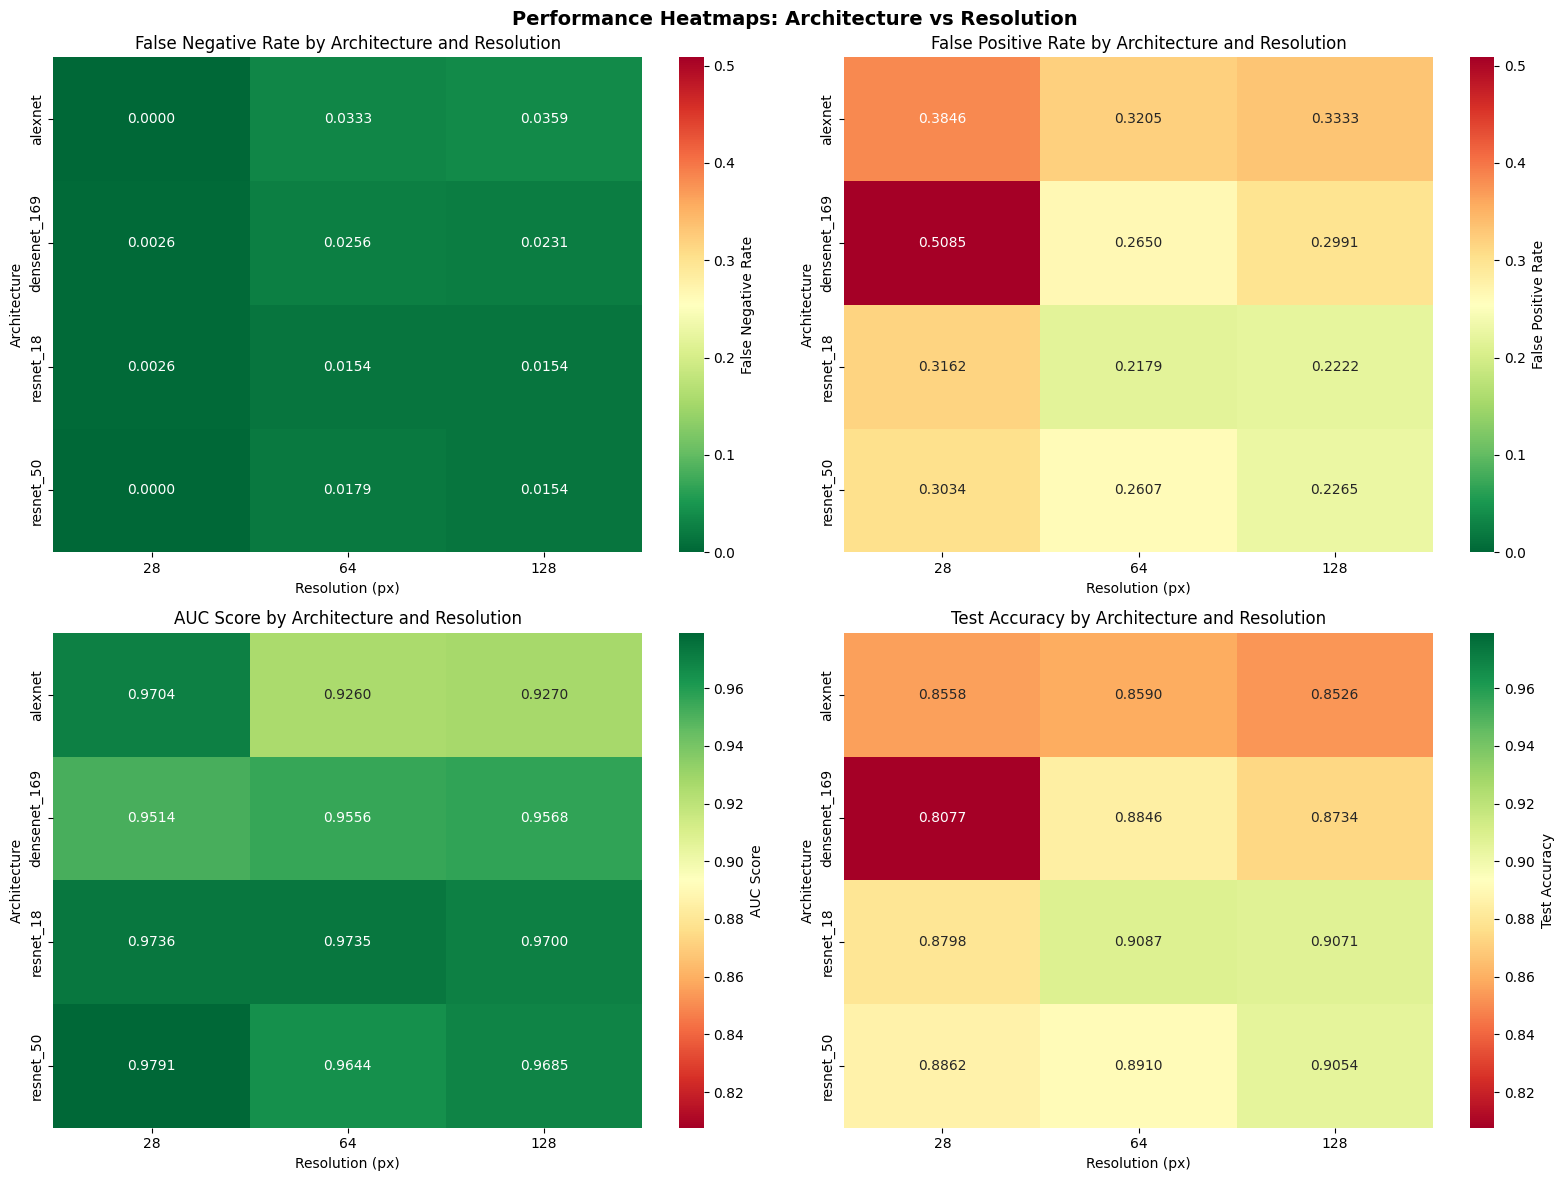

=== DETAILED METRICS SUMMARY ===

Performance by Architecture and Resolution:
(Values show: FN_Rate | AUC | Accuracy)


,Architecture,Resolution,Count,Combined
0,alexnet,28px,1,0.0000 | 0.9704 | 0.8558
1,alexnet,64px,1,0.0333 | 0.9260 | 0.8590
2,alexnet,128px,1,0.0359 | 0.9270 | 0.8526
3,densenet_169,28px,1,0.0026 | 0.9514 | 0.8077
4,densenet_169,64px,1,0.0256 | 0.9556 | 0.8846
5,densenet_169,128px,1,0.0231 | 0.9568 | 0.8734
6,resnet_18,28px,1,0.0026 | 0.9736 | 0.8798
7,resnet_18,64px,1,0.0154 | 0.9735 | 0.9087
8,resnet_18,128px,1,0.0154 | 0.9700 | 0.9071
9,resnet_50,28px,1,0.0000 | 0.9791 | 0.8862



=== BEST PERFORMERS ===
Lowest FN Rate: alexnet_augmented_b96_lr0.001_dr0.5_pneumonia_model.keras
  - FN Rate: 0.000000, AUC: 0.970403, Accuracy: 0.855769
  - Architecture: alexnet, Resolution: 28px, Tuned: False

Highest AUC: resnet_50_augmented_b32_lr0.001_dr0.3_pneumonia_model.keras
  - FN Rate: 0.000000, AUC: 0.979131, Accuracy: 0.886218
  - Architecture: resnet_50, Resolution: 28px, Tuned: False

Highest Accuracy: resnet_18_tuned_augmented_b64_lr0.001_dr0.5_64px_pneumonia_model.keras
  - FN Rate: 0.015385, AUC: 0.973471, Accuracy: 0.908654
  - Architecture: resnet_18, Resolution: 64px, Tuned: True


In [7]:
# Create performance heatmaps
print("Creating performance heatmaps...")
create_performance_heatmaps(model_df)

# Create detailed metrics summary and best performers analysis
summary_df, best_performers = create_detailed_metrics_summary(model_df)

print("=== DETAILED METRICS SUMMARY ===")
print("\nPerformance by Architecture and Resolution:")
print("(Values show: FN_Rate | AUC | Accuracy)")

if not summary_df.empty:
    display(summary_df[['Architecture', 'Resolution', 'Count', 'Combined']])

# Display best performing models
print(f"\n=== BEST PERFORMERS ===")
best_fn = best_performers['lowest_fn']
best_auc = best_performers['highest_auc']
best_acc = best_performers['highest_acc']

print(f"Lowest FN Rate: {best_fn['model_name_from_txt']}")
print(f"  - FN Rate: {best_fn['false_negative_rate']:.6f}, AUC: {best_fn['test_auc']:.6f}, Accuracy: {best_fn['test_accuracy']:.6f}")
print(f"  - Architecture: {best_fn['architecture']}, Resolution: {best_fn['resolution']}px, Tuned: {best_fn['tuned']}")

print(f"\nHighest AUC: {best_auc['model_name_from_txt']}")
print(f"  - FN Rate: {best_auc['false_negative_rate']:.6f}, AUC: {best_auc['test_auc']:.6f}, Accuracy: {best_auc['test_accuracy']:.6f}")
print(f"  - Architecture: {best_auc['architecture']}, Resolution: {best_auc['resolution']}px, Tuned: {best_auc['tuned']}")

print(f"\nHighest Accuracy: {best_acc['model_name_from_txt']}")
print(f"  - FN Rate: {best_acc['false_negative_rate']:.6f}, AUC: {best_acc['test_auc']:.6f}, Accuracy: {best_acc['test_accuracy']:.6f}")
print(f"  - Architecture: {best_acc['architecture']}, Resolution: {best_acc['resolution']}px, Tuned: {best_acc['tuned']}")